In [538]:
import os
import numpy as np
import cv2
import easyocr  
import matplotlib.pyplot as plt

In [539]:
reader = easyocr.Reader(['en'], gpu=False)

panel = cv2.imread('testImage3.png')
panel = np.asarray(panel)

detection = reader.detect(panel)

Using CPU. Note: This module is much faster with a GPU.


In [540]:
detection

([[[np.int32(393), np.int32(455), np.int32(73), np.int32(89)],
   [np.int32(399), np.int32(447), np.int32(85), np.int32(105)],
   [np.int32(525), np.int32(561), np.int32(79), np.int32(99)],
   [np.int32(289), np.int32(379), np.int32(85), np.int32(117)],
   [np.int32(413), np.int32(435), np.int32(105), np.int32(119)],
   [np.int32(505), np.int32(581), np.int32(97), np.int32(115)],
   [np.int32(401), np.int32(449), np.int32(119), np.int32(137)],
   [np.int32(513), np.int32(573), np.int32(113), np.int32(133)],
   [np.int32(393), np.int32(453), np.int32(133), np.int32(153)],
   [np.int32(517), np.int32(569), np.int32(131), np.int32(149)],
   [np.int32(391), np.int32(455), np.int32(149), np.int32(169)],
   [np.int32(515), np.int32(571), np.int32(147), np.int32(167)],
   [np.int32(395), np.int32(455), np.int32(167), np.int32(185)],
   [np.int32(393), np.int32(455), np.int32(181), np.int32(201)],
   [np.int32(415), np.int32(469), np.int32(461), np.int32(481)],
   [np.int32(399), np.int32(469)

In [541]:
def draw_bounding_boxes(image, detection, debug = False):
    ROI = []
    for bbox in detection[0][0]:
        if debug:
            print("bbox = ", bbox)
        cv2.rectangle(panel, pt1=(bbox[0], bbox[2]), pt2=(bbox[1], bbox[3]), color=(0, 255, 0))


In [542]:
#draw_bounding_boxes(panel, detection, False)
#plt.figure(figsize=(20, 10))
#plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
#plt.show()

In [543]:
def extract_ROI(image, detection):
    ROI = []
    for bbox in detection[0][0]:
        ROI.append(panel[bbox[2] : bbox[3], bbox[0]: bbox[1]])
    return ROI

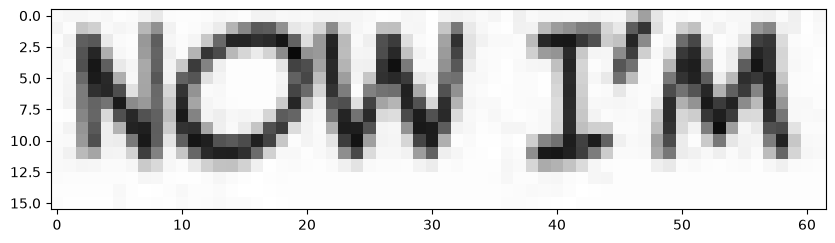

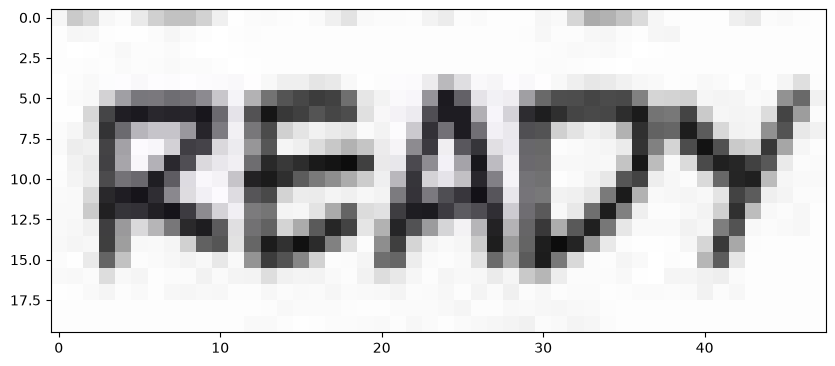

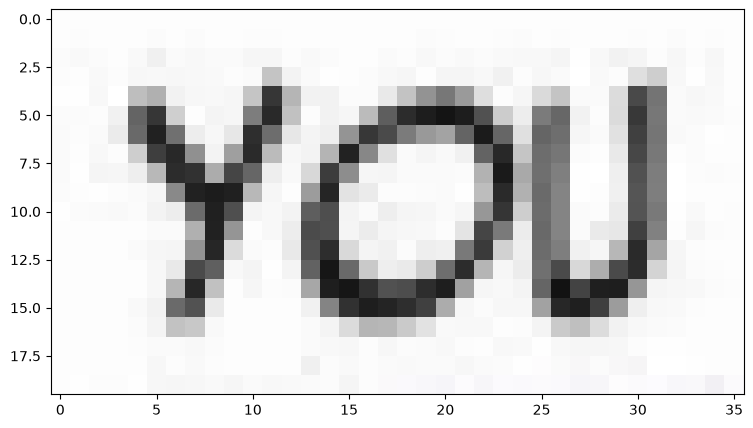

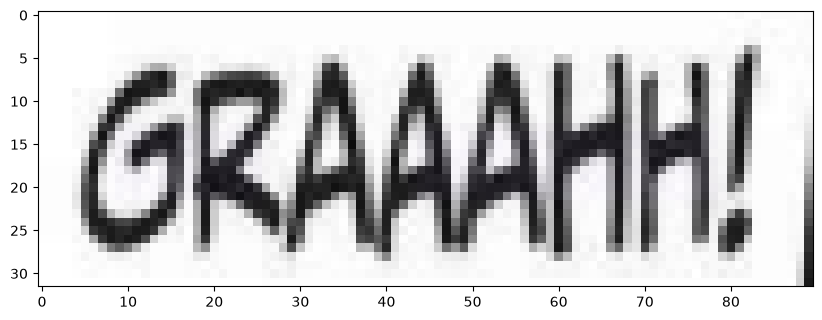

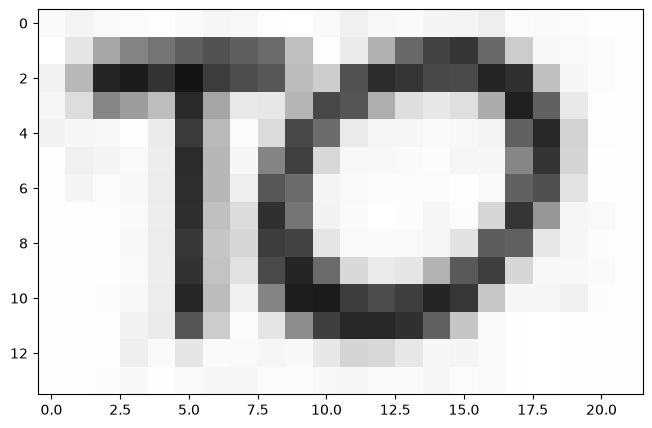

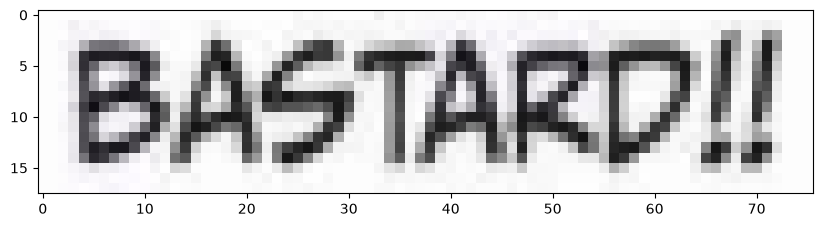

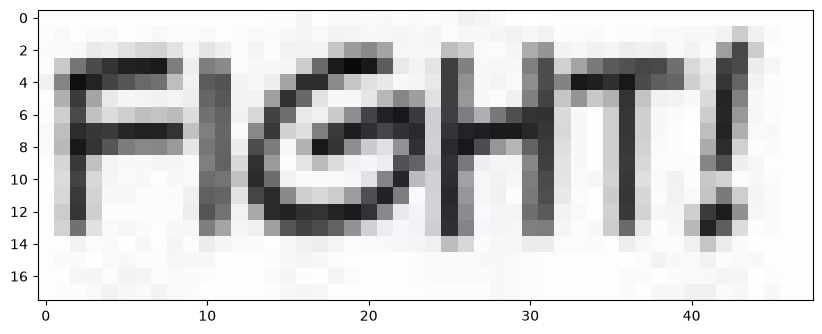

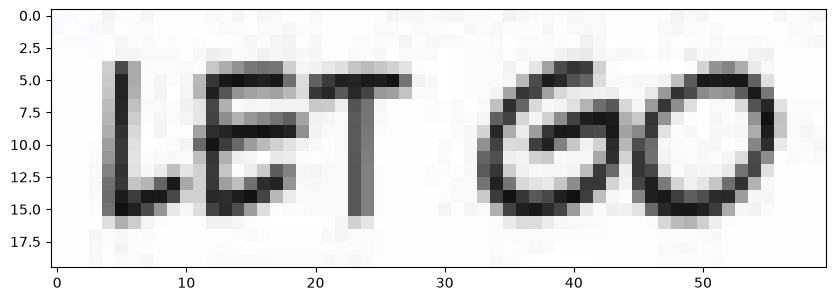

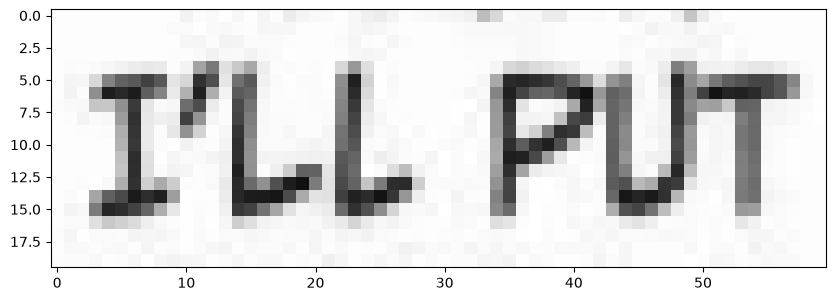

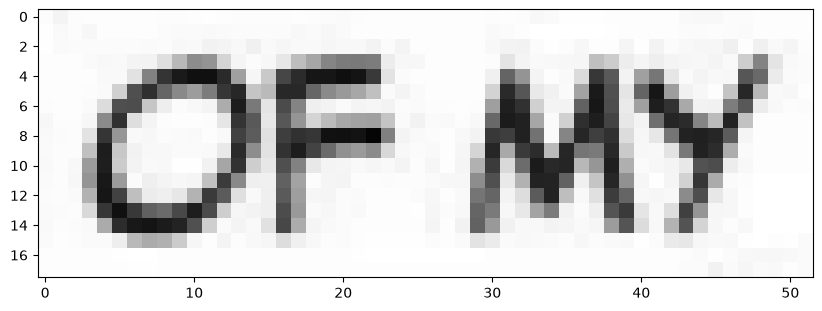

In [544]:
ROI = extract_ROI(panel, detection)

i = 0
for roi in ROI:
    if i < 10:
        plt.figure(figsize=(10, 5))
        plt.imshow(roi)
        plt.show()
        i+=1

In [545]:
def flip_ROI(image, detection, ROI):
    ROI = list(map(np.fliplr, ROI))
    for bbox, roi in zip(detection[0][0], ROI):
        panel[bbox[2] : bbox[3], bbox[0]: bbox[1]] = roi

flip_ROI(panel, detection, ROI)

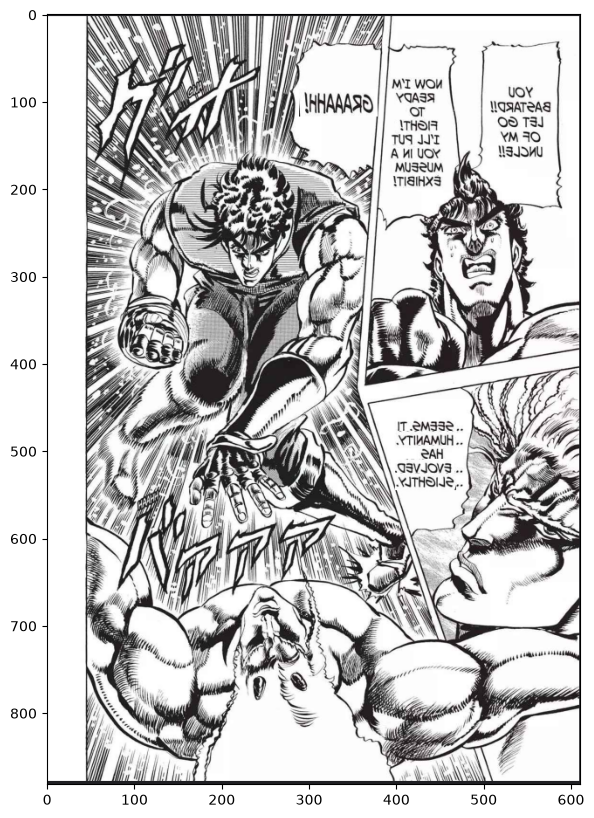

In [546]:
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
plt.show()

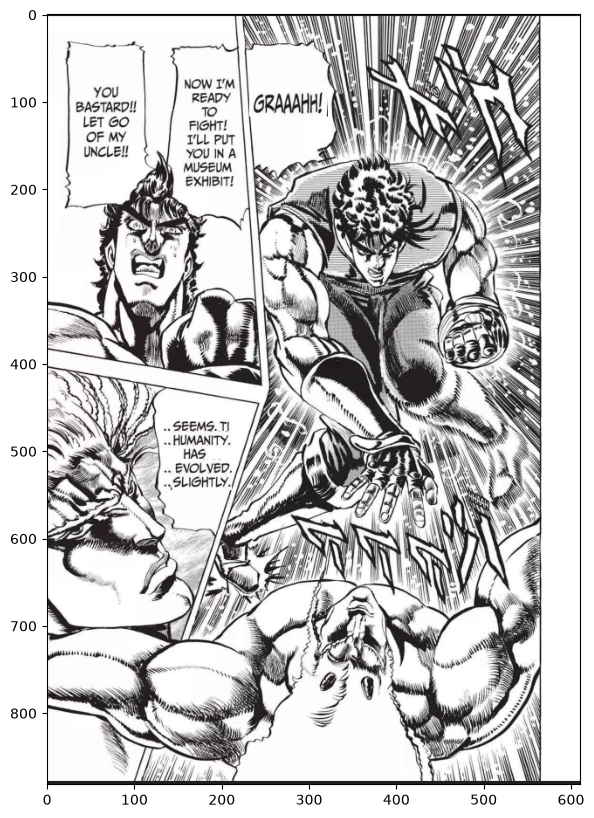

In [547]:
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(np.fliplr(panel), cv2.COLOR_BGR2RGB))
plt.show()